# Generate Fake BPSK Data

See [this article](https://www.site2241.net/january2024.htm)

In [53]:
import numpy as np
import scipy
import commpy

# Parameters
num_symbols = 1000 # Total number of symbols to send
symbol_rate = 1187.5 # symbols per second
sample_rate = 250e3 # samples per second
pilot_tone_freq = 19e3 # Hz
rds_carrier_freq = 57e3 # Hz
pilot_tone_amplitude = 0.1 # Unitless fraction of "full amplitude," which corresponds to max deviation in FM
rds_carrier_amplitude = 0.05 # Unitless fraction of "full amplitude," which corresponds to max deviation in FM

# Calculate how long a symbol lasts
symbol_duration = round(sample_rate / symbol_rate) # Samples per symbol, not exactly correct because we are rounding

# Generate BPSK baseband signal.
bpsk_data = np.random.choice([1, -1], size = num_symbols)
bpsk_data = np.repeat(bpsk_data, symbol_duration)

# Apply root-raised-cosine filter to baseband signal.
_, rrc_filter = commpy.filters.rrcosfilter(symbol_duration * 100, 2.2, 1 / symbol_rate, sample_rate) # See page 10 of RDS standard
bpsk_data_rrc = scipy.signal.lfilter(rrc_filter, [1.0], bpsk_data)
bpsk_data_rrc /= np.max(bpsk_data_rrc) # Normalize amplitude so it still swings from -1 to +1

# Generate the pilot tone real sinusoid
pilot_tone = pilot_tone_amplitude * np.cos(((2 * np.pi * pilot_tone_freq) / sample_rate) * np.arange(len(bpsk_data)))

# Generate the BPSK-modulated signal
rds_signal = rds_carrier_amplitude * bpsk_data_rrc * np.cos(((2 * np.pi * rds_carrier_freq) / sample_rate) * np.arange(len(bpsk_data)))

# Superimpose pilot tone and RDS
complete_baseband = pilot_tone + rds_signal

# Plot Baseband Spectrum

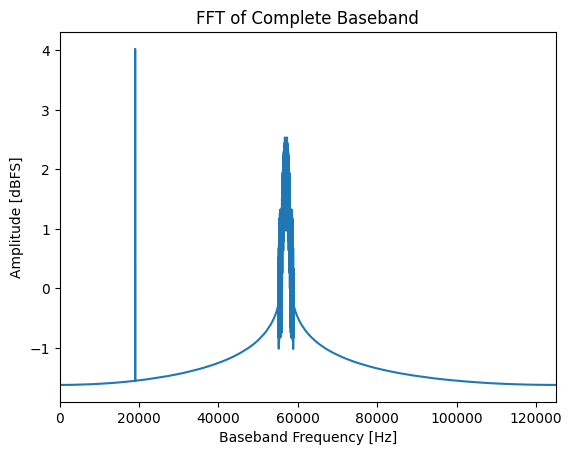

In [63]:
%matplotlib inline
import matplotlib.pyplot as plt

def plot_fft_real(real_signal, sample_rate, title = ""):
    fft = np.fft.fft(real_signal)
    fft = np.fft.fftshift(fft)
    freq_bins = np.linspace(-sample_rate / 2, sample_rate / 2, num = len(fft))
    plt.plot(freq_bins, np.log10(abs(fft)))
    plt.xlim(0, sample_rate / 2)
    plt.xlabel("Baseband Frequency [Hz]")
    plt.ylabel("Amplitude [dBFS]")
    plt.title(title)
    plt.show()

plot_fft_real(complete_baseband, sample_rate, "FFT of Complete Baseband")

# Try Demodulating

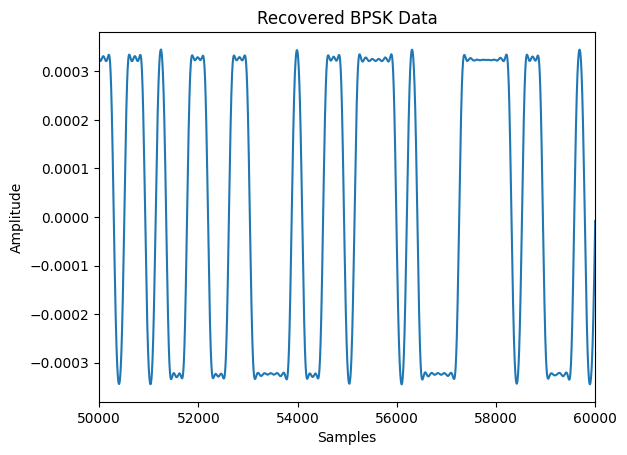

In [92]:
# Extract pilot tone

pilot_tone_bandpass = scipy.signal.firwin(numtaps = 501, cutoff = [16e3, 22e3], fs = sample_rate, pass_zero = "bandpass")
pilot_tone_extracted = scipy.signal.lfilter(pilot_tone_bandpass, [1.0], complete_baseband)

#plot_fft_real(pilot_tone_extracted, sample_rate, "FFT of Extracted Pilot Tone")

# Triple frequency of extracted pilot tone by clipping
pilot_tone_peak = np.max(pilot_tone_extracted)
pilot_tone_clipped = np.clip(pilot_tone_extracted, -pilot_tone_peak / 2, pilot_tone_peak / 2)

#plot_fft_real(pilot_tone_clipped, sample_rate, "FFT of Clipped Pilot Tone")

# Extract tripled tone
rds_carrier_bandpass = scipy.signal.firwin(numtaps = 501, cutoff = [57e3 - 3e3, 57e3 + 3e3], fs = sample_rate, pass_zero = "bandpass")
pilot_tone_tripled_extracted = scipy.signal.lfilter(rds_carrier_bandpass, [1.0], pilot_tone_clipped)

#plot_fft_real(pilot_tone_tripled_extracted, sample_rate, "FFT of Clipped and Bandpassed Pilot Tone")

# Bandpass the baseband for just the RDS
rds_signal = scipy.signal.lfilter(rds_carrier_bandpass, [1.0], complete_baseband)

#plot_fft_real(rds_signal, sample_rate, "RDS Signal Isolated")

# Mix the RDS with the tripled tone
mixed = rds_signal * pilot_tone_tripled_extracted

#plot_fft_real(mixed, sample_rate, "Mixer Output")

# Lowpass mixer output
lowpass = scipy.signal.firwin(numtaps = 501, cutoff = 3e3, fs = sample_rate)
lowpassed_mixed = scipy.signal.lfilter(lowpass, [1.0], mixed)

# Plot time-domain demodulated signal
plt.plot(lowpassed_mixed)
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.title("Recovered BPSK Data")
plt.xlim(50000, 60000)
plt.show()

# Extra: Figuring out RRC Filter

I used the code below to plot the frequency response of the RRC and played with parameters to make it look similar to the one from the RDS standard.

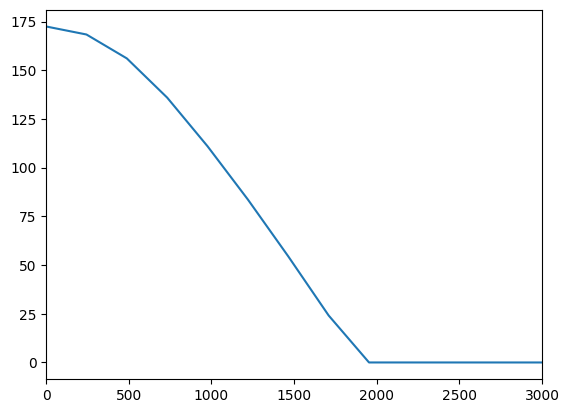

In [49]:
freqs, rrc_frequency_response = scipy.signal.freqz(rrc_filter, fs = sample_rate)
plt.plot(freqs, abs(rrc_frequency_response))
plt.xlim(0, 3e3)
plt.show()